# Task 3: Heart Disease Prediction

## Objective
The objective of this project is to build a machine learning model that predicts whether a patient is at risk of heart disease based on medical and clinical attributes. The project includes data cleaning, exploratory data analysis, model training, and evaluation using classification metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

In [5]:
from google.colab import files
uploaded = files.upload()   # choose heart.csv from your computer

import pandas as pd
df = pd.read_csv("heart_disease_uci.csv")
print(df.shape)
df.head()

Saving heart_disease_uci.csv to heart_disease_uci (2).csv
(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
print(df.columns.tolist())
df.head()


['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
# Convert num to binary target: 0 = no disease, 1 = disease (any severity)
df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
df = df.drop("num", axis=1)
df["target"].value_counts()

,count
target,
1,509
0,411


In [9]:
df = df.drop(columns=["id"], errors="ignore")

In [10]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  target    920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB

Missing values per column:
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch      

In [15]:
df = df.drop(columns=["id", "dataset"], errors="ignore")

if "num" in df.columns:
    df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
    df = df.drop(columns=["num"])

print("Missing values before cleaning:\n", df.isnull().sum())
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(exclude="number").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:\n", df.isnull().sum())
df.head()

Missing values before cleaning:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values after cleaning:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=["object", "bool"]).columns
print("Categorical columns to encode:", list(cat_cols))

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

Categorical columns to encode: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [18]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,131.995652,199.908696,0.150000,0.990217,137.692391,0.366304,0.853261,1.152174,0.227174,1.158696,0.553261
std,9.424685,0.408148,0.956350,18.451300,109.040171,0.357266,0.631863,25.145235,0.482056,1.058049,0.516007,0.628936,0.483493,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,177.750000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,140.000000,0.000000,0.500000,1.000000,0.000000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,1.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


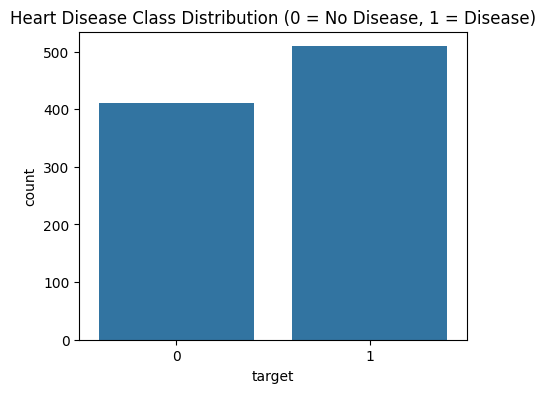

target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


In [19]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="target")
plt.title("Heart Disease Class Distribution (0 = No Disease, 1 = Disease)")
plt.show()

print(df["target"].value_counts(normalize=True))

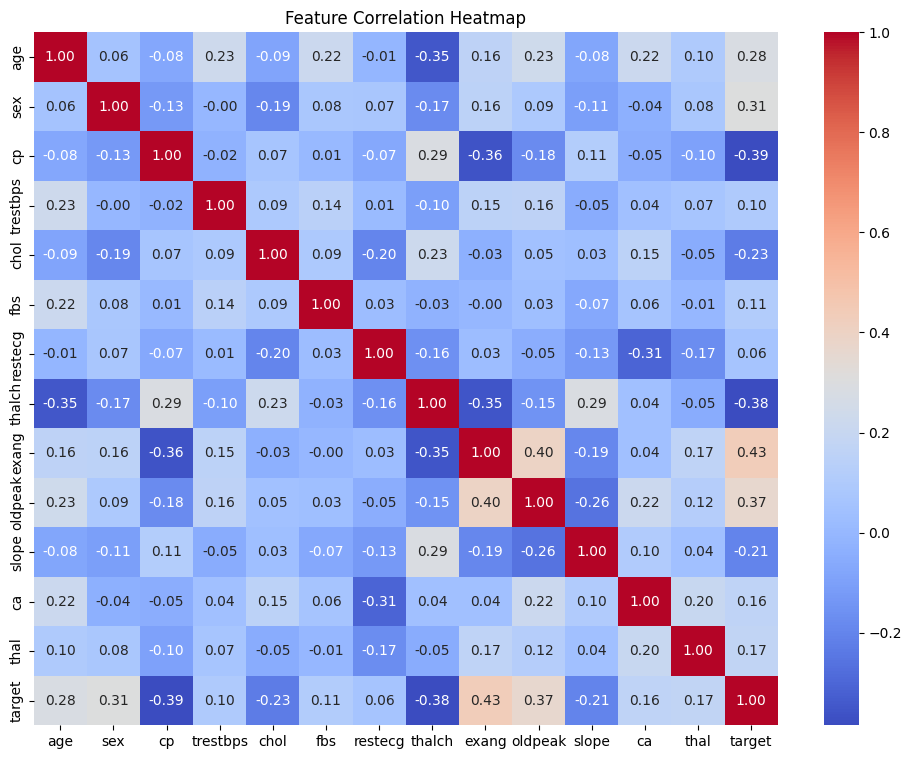

In [20]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

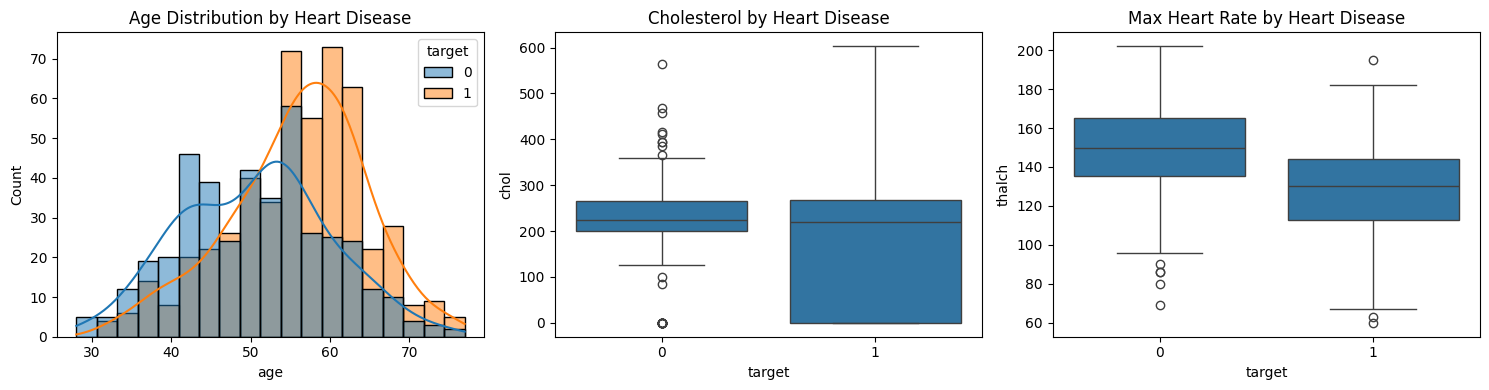

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(data=df, x="age", hue="target", kde=True, ax=axes[0])
axes[0].set_title("Age Distribution by Heart Disease")

sns.boxplot(data=df, x="target", y="chol", ax=axes[1])
axes[1].set_title("Cholesterol by Heart Disease")

sns.boxplot(data=df, x="target", y="thalch", ax=axes[2])
axes[2].set_title("Max Heart Rate by Heart Disease")

plt.tight_layout()
plt.show()

In [22]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(736, 13) (184, 13)


In [23]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("\nClassification Report:\n", classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.8206521739130435

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80        82
           1       0.83      0.84      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



In [24]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
tree_proba = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_preds))
print("\nClassification Report:\n", classification_report(y_test, tree_preds))

Decision Tree Accuracy: 0.7717391304347826

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74        82
           1       0.79      0.79      0.79       102

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184



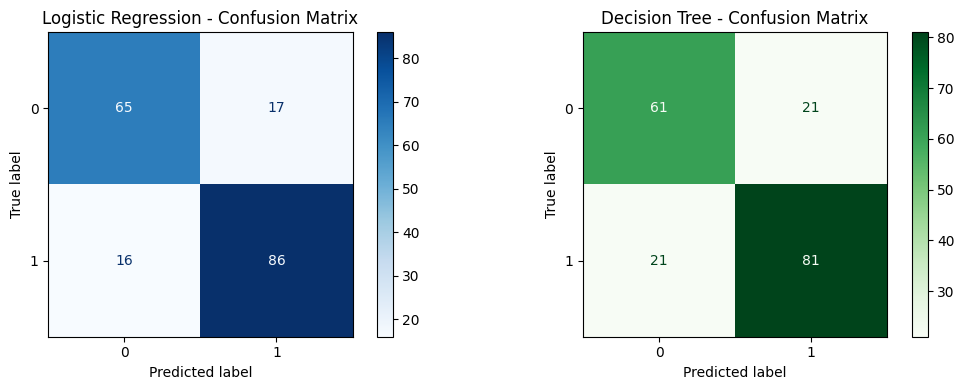

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

cm_log = confusion_matrix(y_test, log_preds)
ConfusionMatrixDisplay(cm_log).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression - Confusion Matrix")

cm_tree = confusion_matrix(y_test, tree_preds)
ConfusionMatrixDisplay(cm_tree).plot(ax=axes[1], cmap="Greens")
axes[1].set_title("Decision Tree - Confusion Matrix")

plt.tight_layout()
plt.show()

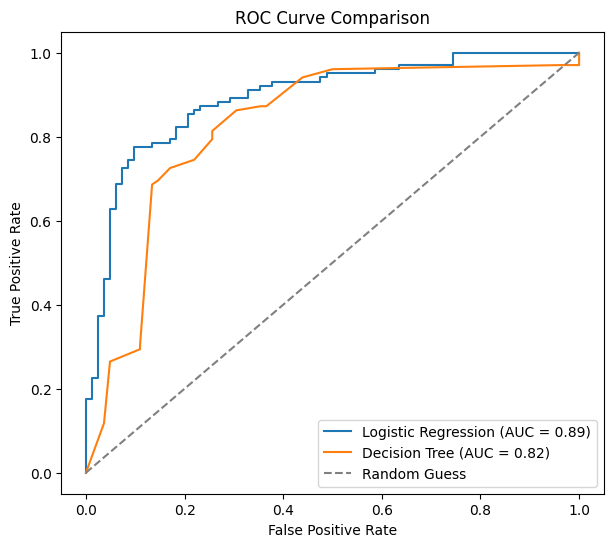

In [26]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_proba)

auc_log = roc_auc_score(y_test, log_proba)
auc_tree = roc_auc_score(y_test, tree_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

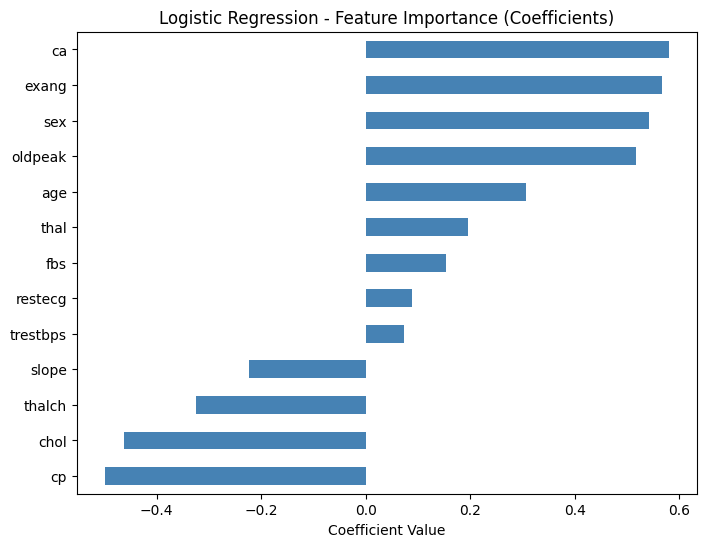

In [27]:
log_importance = pd.Series(log_model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8,6))
log_importance.plot(kind="barh", color="steelblue")
plt.title("Logistic Regression - Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.show()

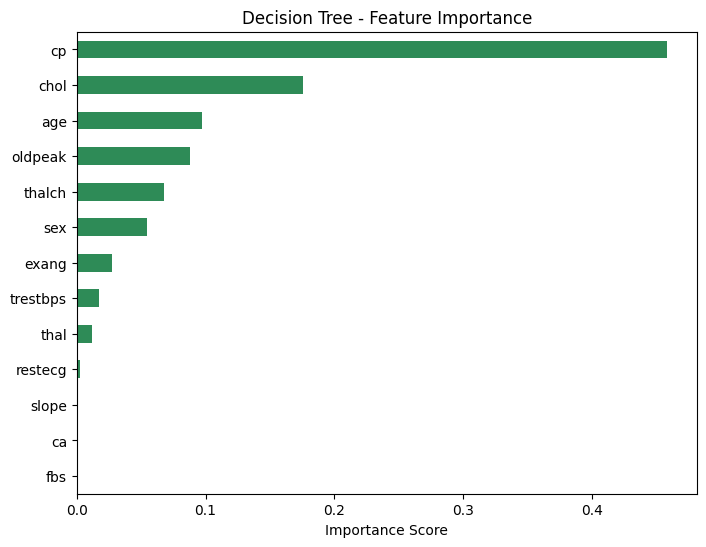

In [28]:
tree_importance = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8,6))
tree_importance.plot(kind="barh", color="seagreen")
plt.title("Decision Tree - Feature Importance")
plt.xlabel("Importance Score")
plt.show()

## Conclusion

- The dataset was cleaned and preprocessed successfully.
- Logistic Regression and Decision Tree models were trained for heart disease prediction.
- Model performance was evaluated using Accuracy, Confusion Matrix, ROC Curve, and AUC Score.
- Several clinical features showed strong influence on heart disease prediction.
- The project demonstrates the practical application of machine learning in healthcare analytics.